In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import sys
sys.path.append('../')
from src.custom_fastkan import FastKAN
import pandas as pd

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
NU = 0.01
ALPHA = 0.1
NI = 2500
NO = 150

def true_function(z):
    x = z[:, 0]
    t = z[:, 1]
    return torch.exp(-NU * (torch.pi ** 2) * t) * torch.sin(torch.pi * x)

def pde_residual(model, z):
    # r(x,t) = u_t - nu * u_xx
    z = z.detach().clone().requires_grad_(True)
    u = model(z)
    u = u.view(-1)
    grads = torch.autograd.grad(u, z, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    u_x = grads[:, 0]
    u_t = grads[:, 1]
    grads_x = torch.autograd.grad(u_x, z, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True)[0]
    u_xx = grads_x[:, 0]
    return u_t - NU * u_xx


def pinn_loss(model, X_obs, y_obs, X_interior):
    pred_o = model(X_obs).view(-1)
    loss_o = torch.mean((pred_o - y_obs) ** 2)
    r = pde_residual(model, X_interior)
    loss_i = torch.mean(r ** 2)
    loss = loss_o + ALPHA * loss_i
    return loss, loss_o, loss_i

torch.manual_seed(42)
# Observation points: IC + boundaries
no_ic = NO // 3
no_b0 = NO // 3
no_b1 = NO - no_ic - no_b0

x_ic = torch.rand(no_ic, 1)
t_ic = torch.zeros(no_ic, 1)

x_b0 = torch.zeros(no_b0, 1)
t_b0 = torch.rand(no_b0, 1)

x_b1 = torch.ones(no_b1, 1)
t_b1 = torch.rand(no_b1, 1)

X_train = torch.cat([
    torch.cat([x_ic, t_ic], dim=1),
    torch.cat([x_b0, t_b0], dim=1),
    torch.cat([x_b1, t_b1], dim=1),
], dim=0)

y_train = true_function(X_train)

# Interior collocation points
eps = 1e-6
X_interior = torch.rand(NI, 2) * (1 - 2 * eps) + eps

# Validation + test points (for reporting only)
X_val = torch.rand(1000, 2)
y_val = true_function(X_val)

X_test = torch.rand(3000, 2)
y_test = true_function(X_test)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_interior = X_interior.to(device)

X_val = X_val.to(device)
y_val = y_val.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape, no_b0, no_b1, no_ic}")

Train shape: torch.Size([150, 2]), Val shape: torch.Size([1000, 2]), Test shape: (torch.Size([3000, 2]), 50, 50, 50)


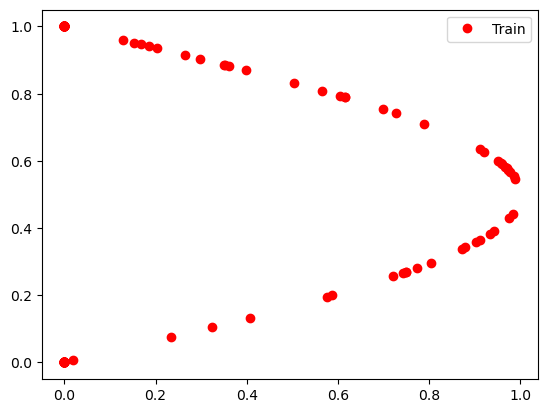

In [4]:
plt.plot(y_train.cpu().numpy(), X_train.cpu().numpy()[:, 0], 'ro', label='Train')
# plt.plot(y_val.cpu().numpy(), X_val.cpu().numpy()[:, 0], 'go', label='Val')
# plt.plot(y_test.cpu().numpy(), X_test.cpu().numpy()[:, 0], 'bo', label='Test')
plt.legend()

In [8]:
# Best-performing KAN config
KAN_LAYERS = [2, 10, 2, 1]

model = FastKAN(KAN_LAYERS, grid_min=-1, grid_max=1, num_grids=10, use_base_update=False, use_layernorm=False).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

sum(p.numel() for p in model.parameters() if p.requires_grad)

420

In [9]:
print("Training KAN...")
train_losses = []
val_losses = []

for epoch in range(2000):
    optimizer.zero_grad()
    loss, loss_o, loss_i = pinn_loss(model, X_train, y_train, X_interior)
    loss.backward()
    optimizer.step()
    
    if epoch % 250 == 0:
        with torch.no_grad():
            val_pred = model(X_val).squeeze()
            val_loss = torch.mean((val_pred - y_val) ** 2)
            train_losses.append(loss.item())
            val_losses.append(val_loss.item())
            print(f"Epoch {epoch}, Train MSE: {loss.item():.6f}, Val MSE: {val_loss.item():.6f}")

model.eval()
with torch.no_grad():
    test_pred = model(X_test).squeeze()
    mse = mean_squared_error(y_test.cpu(), test_pred.cpu())
    r2 = r2_score(y_test.cpu(), test_pred.cpu())
    
    print(f"KAN Test MSE: {mse:.6f}")
    print(f"KAN Test R2: {r2:.4f}")

Training KAN...
Epoch 0, Train MSE: 0.173024, Val MSE: 0.307696
Epoch 250, Train MSE: 0.000284, Val MSE: 0.000535
Epoch 500, Train MSE: 0.000015, Val MSE: 0.000002
Epoch 750, Train MSE: 0.000009, Val MSE: 0.000002
Epoch 1000, Train MSE: 0.000005, Val MSE: 0.000001
Epoch 1250, Train MSE: 0.000021, Val MSE: 0.000006
Epoch 1500, Train MSE: 0.000214, Val MSE: 0.000496
Epoch 1750, Train MSE: 0.000003, Val MSE: 0.000001
KAN Test MSE: 0.000000
KAN Test R2: 1.0000


In [5]:
import torch.nn as nn
torch.manual_seed(42)

class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=[64, 64], output_dim=1):
        super(MLP, self).__init__()
        layers = []
        curr_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.Tanh())
            curr_dim = h_dim
        layers.append(nn.Linear(curr_dim, output_dim))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# Best-performing MLP config
MLP_HIDDEN_DIMS = [64, 64]

mlp_model = MLP(input_dim=2, hidden_dims=MLP_HIDDEN_DIMS, output_dim=1).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01)

print("Training MLP...")
for epoch in range(2000):
    mlp_model.train()
    mlp_optimizer.zero_grad()

    loss, loss_o, loss_i = pinn_loss(mlp_model, X_train, y_train, X_interior)
    loss.backward()
    mlp_optimizer.step()
    
    if epoch % 250 == 0:
        mlp_model.eval()
        with torch.no_grad():
            val_pred = mlp_model(X_val).squeeze()
            val_loss = torch.mean((val_pred - y_val) ** 2)
            print(f"Epoch {epoch}, Train MSE: {loss.item():.6f}, Val MSE: {val_loss.item():.6f}")

mlp_model.eval()
with torch.no_grad():
    mlp_pred = mlp_model(X_test).squeeze()
    mlp_mse = mean_squared_error(y_test.cpu(), mlp_pred.cpu())
    mlp_r2 = r2_score(y_test.cpu(), mlp_pred.cpu())
    
    print(f"\nMLP Test MSE: {mlp_mse:.6f}")
    print(f"MLP Test R2: {mlp_r2:.4f}")

Training MLP...
Epoch 0, Train MSE: 0.192440, Val MSE: 0.094458
Epoch 250, Train MSE: 0.000033, Val MSE: 0.000019
Epoch 500, Train MSE: 0.000008, Val MSE: 0.000002
Epoch 750, Train MSE: 0.000368, Val MSE: 0.000176
Epoch 1000, Train MSE: 0.000005, Val MSE: 0.000002
Epoch 1250, Train MSE: 0.000004, Val MSE: 0.000002
Epoch 1500, Train MSE: 0.000004, Val MSE: 0.000001
Epoch 1750, Train MSE: 0.000048, Val MSE: 0.000052

MLP Test MSE: 0.000002
MLP Test R2: 1.0000


In [6]:
print("\nAnalyzing individual KAN prediction losses...")
individual_losses = []
predictions = []
with torch.no_grad():
    for i in range(len(X_test)):
        input_seq = X_test[i]
        ground_truth = y_test[i]
        prediction = model(input_seq.unsqueeze(0)).squeeze()
        
        loss = ((prediction - ground_truth) ** 2).item()
        individual_losses.append(loss)
        predictions.append(prediction)

individual_losses = np.array(individual_losses)
predictions = torch.stack(predictions)
sorted_indices = np.argsort(individual_losses)

mean_loss = np.mean(individual_losses)
lowest_indices = sorted_indices[:3] 
highest_indices = sorted_indices[-3:]

mean_distances = np.abs(individual_losses - mean_loss)
mean_sorted_indices = np.argsort(mean_distances)
mean_indices = mean_sorted_indices[:3]

print(f"\nKAN Loss Statistics:")
print(f"Mean Loss: {mean_loss:.6f}")
print(f"Min Loss: {individual_losses[lowest_indices[0]]:.6f}")
print(f"Max Loss: {individual_losses[highest_indices[-1]]:.6f}")


Analyzing individual KAN prediction losses...

KAN Loss Statistics:
Mean Loss: 0.000000
Min Loss: 0.000000
Max Loss: 0.000005


In [7]:
print("\nAnalyzing individual MLP prediction losses...")
mlp_individual_losses = []
mlp_predictions = []

mlp_model.eval()
with torch.no_grad():
    for i in range(len(X_test)):
        input_seq = X_test[i]
        ground_truth = y_test[i]
        prediction = mlp_model(input_seq.unsqueeze(0)).squeeze()
        
        loss = ((prediction - ground_truth) ** 2).item()
        mlp_individual_losses.append(loss)
        mlp_predictions.append(prediction)

mlp_individual_losses = np.array(mlp_individual_losses)
mlp_predictions = torch.stack(mlp_predictions)
mlp_sorted_indices = np.argsort(mlp_individual_losses)

mlp_mean_loss = np.mean(mlp_individual_losses)
mlp_lowest_indices = mlp_sorted_indices[:3] 
mlp_highest_indices = mlp_sorted_indices[-3:]

mlp_mean_distances = np.abs(mlp_individual_losses - mlp_mean_loss)
mlp_mean_sorted_indices = np.argsort(mlp_mean_distances)
mlp_mean_indices = mlp_mean_sorted_indices[:3]

print(f"\nMLP Loss Statistics:")
print(f"Mean Loss: {mlp_mean_loss:.6f}")
print(f"Min Loss: {mlp_individual_losses[mlp_lowest_indices[0]]:.6f}")
print(f"Max Loss: {mlp_individual_losses[mlp_highest_indices[-1]]:.6f}")


Analyzing individual MLP prediction losses...

MLP Loss Statistics:
Mean Loss: 0.000002
Min Loss: 0.000000
Max Loss: 0.000013


In [8]:
table_data = []
categories = [("Lowest", lowest_indices), ("Highest", highest_indices), ("Mean", mean_indices)]

for label, indices in categories:
    for idx in indices:
        table_data.append({
            "Category": label,
            "Index": idx,
            "Input (x, t)": f"({X_test[idx][0].item():.4f}, {X_test[idx][1].item():.4f})",
            "True Value": y_test[idx].item(),
            "Predicted": predictions[idx].item(),
            "Loss": individual_losses[idx]
        })

df_kan_analysis = pd.DataFrame(table_data)
df_kan_analysis

,Category,Index,"Input (x, t)",True Value,Predicted,Loss
0,Lowest,2903,"(0.2135, 0.9013)",0.568650,0.568650,1.740830e-13
1,Lowest,1359,"(0.1964, 0.7263)",0.538555,0.538556,1.282530e-12
2,Lowest,1356,"(0.5859, 0.0083)",0.962981,0.962980,2.046363e-12
3,Highest,2878,"(0.9965, 0.7875)",0.010234,0.008654,2.499197e-06
4,Highest,1461,"(0.0017, 0.9790)",0.004911,0.006654,3.037859e-06
5,Highest,538,"(0.0085, 0.9940)",0.024129,0.026275,4.603342e-06
6,Mean,1610,"(0.9816, 0.9581)",0.052548,0.052996,2.002834e-07
7,Mean,1562,"(0.4071, 0.7011)",0.893650,0.894097,2.001067e-07
8,Mean,2075,"(0.8711, 0.8570)",0.361922,0.362370,1.999467e-07


In [9]:
table_data_mlp = []
categories = [("Lowest", mlp_lowest_indices), ("Highest", mlp_highest_indices), ("Mean", mlp_mean_indices)]

for label, indices in categories:
    for idx in indices:
        table_data_mlp.append({
            "Category": label,
            "Index": idx,
            "Input (x, t)": f"({X_test[idx][0].item():.4f}, {X_test[idx][1].item():.4f})",
            "True Value": y_test[idx].item(),
            "Predicted": mlp_predictions[idx].item(),
            "Loss": mlp_individual_losses[idx]
        })

df_mlp_analysis = pd.DataFrame(table_data_mlp)
df_mlp_analysis

,Category,Index,"Input (x, t)",True Value,Predicted,Loss
0,Lowest,2755,"(0.6170, 0.6034)",0.879300,0.879300,0.000000e+00
1,Lowest,1492,"(0.0988, 0.1664)",0.300420,0.300421,1.719513e-12
2,Lowest,830,"(0.1844, 0.5693)",0.517654,0.517652,2.401634e-12
3,Highest,293,"(0.4889, 0.1935)",0.980491,0.976904,1.286833e-05
4,Highest,2750,"(0.4948, 0.1797)",0.982287,0.978699,1.287518e-05
5,Highest,2314,"(0.4893, 0.1914)",0.980731,0.977143,1.287560e-05
6,Mean,2543,"(0.8521, 0.5311)",0.425206,0.423834,1.881593e-06
7,Mean,2863,"(0.2912, 0.7872)",0.733290,0.734662,1.881347e-06
8,Mean,2621,"(0.3213, 0.6808)",0.791512,0.792882,1.878569e-06


In [10]:
mlp_save_path = "model_pkls/pinnheat_mlp_model.pkl"
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'config': {
        'input_dim': 2,
        'hidden_dims': MLP_HIDDEN_DIMS,
        'output_dim': 1
    }
}, mlp_save_path)
print(f"MLP Model saved to {mlp_save_path}")

MLP Model saved to model_pkls/pinnheat_mlp_model.pkl


In [11]:
kan_save_path = "../model_pkls/pinnheat_kan_model.pkl"
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'layers_hidden': KAN_LAYERS,
        'grid_min': -1,
        'grid_max': 1,
        'num_grids': 10,
        'use_base_update': False,
        'use_layernorm': False,
    }
}, kan_save_path)
print(f"KAN Model saved to {kan_save_path}")

KAN Model saved to ../model_pkls/pinnheat_kan_model.pkl
